In [3]:
import json 
import os
from aeon.visualisation import plot_critical_difference
import pandas as pd

In [15]:
CTX_LEN=512

In [16]:
with open(os.path.join(f"../raw_results/CausalRevIN_False/{CTX_LEN}", "results_gift_eval.json"), "r") as f:
    metrics_causal_gift_eval = json.load(f)
#with open(os.path.join(f"../raw_results/CausalRevIN_False/{CTX_LEN}", "results_utsd.json"), "r") as f:
#    metrics_causal_utsd = json.load(f)
with open(os.path.join(f"../raw_results/CausalRevIN_False/{CTX_LEN}", "results_artificial.json"), "r") as f:
    metrics_causal_artificial = json.load(f)

with open(os.path.join(f"../raw_results/CausalRevIN_True/{CTX_LEN}", "results_gift_eval.json"), "r") as f:
    metrics_causal_asinh_gift_eval = json.load(f)
#with open(os.path.join(f"../raw_results/CausalRevIN_True/{CTX_LEN}", "results_utsd.json"), "r") as f:
#    metrics_causal_asinh_utsd = json.load(f)
with open(os.path.join(f"../raw_results/CausalRevIN_True/{CTX_LEN}", "results_artificial.json"), "r") as f:
    metrics_causal_asinh_artificial = json.load(f)

with open(os.path.join(f"../raw_results/RevIN_True/{CTX_LEN}", "results_gift_eval.json"), "r") as f:
    metrics_asinh_gift_eval = json.load(f)
#with open(os.path.join(f"../raw_results/RevIN_True/{CTX_LEN}", "results_utsd.json"), "r") as f:
#    metrics_asinh_utsd = json.load(f)
with open(os.path.join(f"../raw_results/RevIN_True/{CTX_LEN}", "results_artificial.json"), "r") as f:
    metrics_asinh_artificial = json.load(f)

with open(os.path.join(f"../raw_results/RevIN_False/{CTX_LEN}", "results_gift_eval.json"), "r") as f:
    metrics_gift_eval = json.load(f)
#with open(os.path.join(f"../raw_results/RevIN_False/{CTX_LEN}", "results_utsd.json"), "r") as f:
#    metrics_utsd = json.load(f)
with open(os.path.join(f"../raw_results/RevIN_False/{CTX_LEN}", "results_artificial.json"), "r") as f:
    metrics_artificial = json.load(f)

with open(os.path.join(f"../raw_results/PrefixRevIN_False/{CTX_LEN}", "results_gift_eval.json"), "r") as f:
    metrics_Prefix_gift_eval = json.load(f)
#with open(os.path.join(f"../raw_results/PrefixRevIN_False/{CTX_LEN}", "results_utsd.json"), "r") as f:
#    metrics_Prefix_utsd = json.load(f)
with open(os.path.join(f"../raw_results/PrefixRevIN_False/{CTX_LEN}", "results_artificial.json"), "r") as f:
    metrics_Prefix_artificial = json.load(f)

with open(os.path.join(f"../raw_results/PrefixRevIN_True/{CTX_LEN}", "results_gift_eval.json"), "r") as f:
    metrics_Prefix_asinh_gift_eval = json.load(f)
#with open(os.path.join(f"../raw_results/PrefixRevIN_True/{CTX_LEN}", "results_utsd.json"), "r") as f:
#    metrics_Prefix_asinh_utsd = json.load(f)
with open(os.path.join(f"../raw_results/PrefixRevIN_True/{CTX_LEN}", "results_artificial.json"), "r") as f:
    metrics_Prefix_asinh_artificial = json.load(f)

# Critical Rank Diagram

In [17]:
full_df = {}
full_df['Causal RevIN'] = {
    'GIFT-Eval': metrics_causal_gift_eval,
    #'UTSD': metrics_causal_utsd,
    'Artificial': metrics_causal_artificial
}
full_df['Causal RevIN + asinh'] = {
    'GIFT-Eval': metrics_causal_asinh_gift_eval,
    #'UTSD': metrics_causal_asinh_utsd,
    'Artificial': metrics_causal_asinh_artificial
}
full_df['RevIN + asinh'] = {
    'GIFT-Eval': metrics_asinh_gift_eval,
    #'UTSD': metrics_asinh_utsd,
    'Artificial': metrics_asinh_artificial
}
full_df['RevIN'] = {
    'GIFT-Eval': metrics_gift_eval,
    #'UTSD': metrics_utsd,
    'Artificial': metrics_artificial
}
full_df['Prefix RevIN'] = {
    'GIFT-Eval': metrics_Prefix_gift_eval,
    #'UTSD': metrics_Prefix_utsd,
    'Artificial': metrics_Prefix_artificial
}
full_df['Prefix RevIN + asinh'] = {
    'GIFT-Eval': metrics_Prefix_asinh_gift_eval,
    #'UTSD': metrics_Prefix_asinh_utsd,
    'Artificial': metrics_Prefix_asinh_artificial
}

In [18]:
new_df_mae = {}
new_df_mse = {}
new_df_mase = {}
for model_name, datasets in full_df.items():
    new_df_mae[model_name] = {}
    new_df_mse[model_name] = {}
    new_df_mase[model_name] = {}
    for dataset_name, metrics in datasets.items():
        for k, v in metrics.items():
            metric, size = k.split("_")
            for signal_idx, signal_metric in v.items():
                if metric.lower() == "mae":
                    new_df_mae[model_name][f"{dataset_name}_{size}_{signal_idx}"] = signal_metric
                elif metric.lower() == "rmse":
                    new_df_mse[model_name][f"{dataset_name}_{size}_{signal_idx}"] = signal_metric
                elif metric.lower() == "mase":
                    new_df_mase[model_name][f"{dataset_name}_{size}_{signal_idx}"] = signal_metric

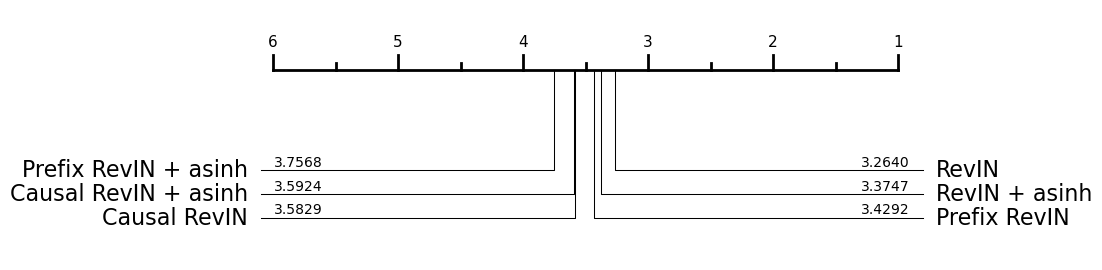

In [19]:
# Create Critical Difference plot for MAE
df_mae = pd.DataFrame(new_df_mae)
methods = df_mae.columns
plot = plot_critical_difference(df_mae.values, methods, alpha=0.05, width=8, test='nemenyi', lower_better=True)

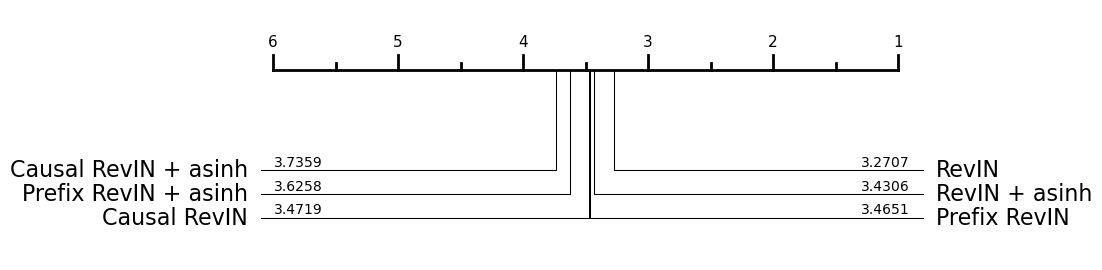

In [13]:
# Create Critical Difference plot for MAE
df_mse = pd.DataFrame(new_df_mse)
methods = df_mse.columns
plot = plot_critical_difference(df_mse.values, methods, alpha=0.05, width=8, test='nemenyi', lower_better=True)

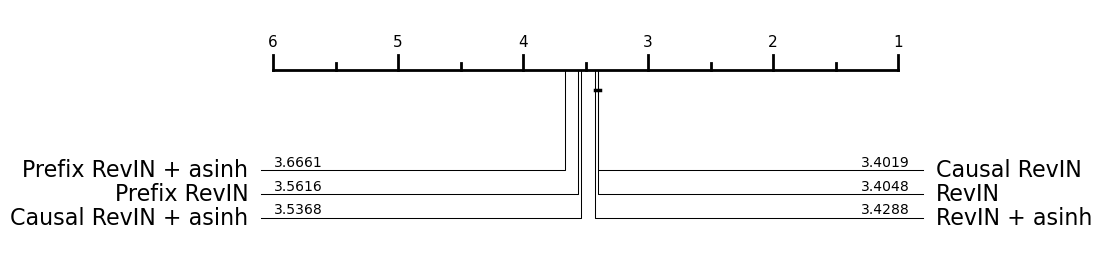

In [14]:
# Create Critical Difference plot for MASE
df_mase = pd.DataFrame(new_df_mase)
methods = df_mase.columns
plot = plot_critical_difference(df_mase.values, methods, alpha=0.05, width=8, test='nemenyi', lower_better=True)

In [ ]:
# overall with all context lengths
CTX_LENS = [128, 256, 512]
full_df = {}
for CTX_LEN in CTX_LENS:

    with open(os.path.join(f"../raw_results/CausalRevIN_False/{CTX_LEN}", "results_gift_eval.json"), "r") as f:
        metrics_causal_gift_eval = json.load(f)
    with open(os.path.join(f"../raw_results/CausalRevIN_False/{CTX_LEN}", "results_utsd.json"), "r") as f:
        metrics_causal_utsd = json.load(f)
    with open(os.path.join(f"../raw_results/CausalRevIN_False/{CTX_LEN}", "results_artificial.json"), "r") as f:
        metrics_causal_artificial = json.load(f)

    with open(os.path.join(f"../raw_results/CausalRevIN_True/{CTX_LEN}", "results_gift_eval.json"), "r") as f:
        metrics_causal_asinh_gift_eval = json.load(f)
    with open(os.path.join(f"../raw_results/CausalRevIN_True/{CTX_LEN}", "results_utsd.json"), "r") as f:
        metrics_causal_asinh_utsd = json.load(f)
    with open(os.path.join(f"../raw_results/CausalRevIN_True/{CTX_LEN}", "results_artificial.json"), "r") as f:
        metrics_causal_asinh_artificial = json.load(f)

    with open(os.path.join(f"../raw_results/RevIN_True/{CTX_LEN}", "results_gift_eval.json"), "r") as f:
        metrics_asinh_gift_eval = json.load(f)
    with open(os.path.join(f"../raw_results/RevIN_True/{CTX_LEN}", "results_utsd.json"), "r") as f:
        metrics_asinh_utsd = json.load(f)
    with open(os.path.join(f"../raw_results/RevIN_True/{CTX_LEN}", "results_artificial.json"), "r") as f:
        metrics_asinh_artificial = json.load(f)

    with open(os.path.join(f"../raw_results/RevIN_False/{CTX_LEN}", "results_gift_eval.json"), "r") as f:
        metrics_gift_eval = json.load(f)
    with open(os.path.join(f"../raw_results/RevIN_False/{CTX_LEN}", "results_utsd.json"), "r") as f:
        metrics_utsd = json.load(f)
    with open(os.path.join(f"../raw_results/RevIN_False/{CTX_LEN}", "results_artificial.json"), "r") as f:
        metrics_artificial = json.load(f)

    with open(os.path.join(f"../raw_results/PrefixRevIN_False/{CTX_LEN}", "results_gift_eval.json"), "r") as f:
        metrics_Prefix_gift_eval = json.load(f)
    with open(os.path.join(f"../raw_results/PrefixRevIN_False/{CTX_LEN}", "results_utsd.json"), "r") as f:
        metrics_Prefix_utsd = json.load(f)
    with open(os.path.join(f"../raw_results/PrefixRevIN_False/{CTX_LEN}", "results_artificial.json"), "r") as f:
        metrics_Prefix_artificial = json.load(f)

    with open(os.path.join(f"../raw_results/PrefixRevIN_True/{CTX_LEN}", "results_gift_eval.json"), "r") as f:
        metrics_Prefix_asinh_gift_eval = json.load(f)
    with open(os.path.join(f"../raw_results/PrefixRevIN_True/{CTX_LEN}", "results_utsd.json"), "r") as f:
        metrics_Prefix_asinh_utsd = json.load(f)
    with open(os.path.join(f"../raw_results/PrefixRevIN_True/{CTX_LEN}", "results_artificial.json"), "r") as f:
        metrics_Prefix_asinh_artificial = json.load(f)
    
    full_df[CTX_LEN] = {}
    full_df[CTX_LEN]['Causal RevIN'] = {
        'GIFT-Eval': metrics_causal_gift_eval,
        'UTSD': metrics_causal_utsd,
        'Artificial': metrics_causal_artificial
    }
    full_df[CTX_LEN]['Causal RevIN + asinh'] = {
        'GIFT-Eval': metrics_causal_asinh_gift_eval,
        'UTSD': metrics_causal_asinh_utsd,
        'Artificial': metrics_causal_asinh_artificial
    }
    full_df[CTX_LEN]['RevIN + asinh'] = {
        'GIFT-Eval': metrics_asinh_gift_eval,
        'UTSD': metrics_asinh_utsd,
        'Artificial': metrics_asinh_artificial
    }
    full_df[CTX_LEN]['RevIN'] = {
        'GIFT-Eval': metrics_gift_eval,
        'UTSD': metrics_utsd,
        'Artificial': metrics_artificial
    }
    full_df[CTX_LEN]['Prefix RevIN'] = {
        'GIFT-Eval': metrics_Prefix_gift_eval,
        'UTSD': metrics_Prefix_utsd,
        'Artificial': metrics_Prefix_artificial
    }
    full_df[CTX_LEN]['Prefix RevIN + asinh'] = {
        'GIFT-Eval': metrics_Prefix_asinh_gift_eval,
        'UTSD': metrics_Prefix_asinh_utsd,
        'Artificial': metrics_Prefix_asinh_artificial
    }
new_df_mae = {}
new_df_mse = {}
for CTX_LEN in CTX_LENS:
    for model_name, datasets in full_df[CTX_LEN].items():
        key_prefix = f"{model_name}"
        if key_prefix not in new_df_mae:
            new_df_mae[key_prefix] = {}
            new_df_mse[key_prefix] = {}
        for dataset_name, metrics in datasets.items():
            for k, v in metrics.items():
                metric, size = k.split("_")
                if metric.lower() == "mae":
                    new_df_mae[key_prefix][f"{dataset_name}_{CTX_LEN}_{size}"] = v
                elif metric.lower() == "rmse":
                    new_df_mse[key_prefix][f"{dataset_name}_{CTX_LEN}_{size}"] = v

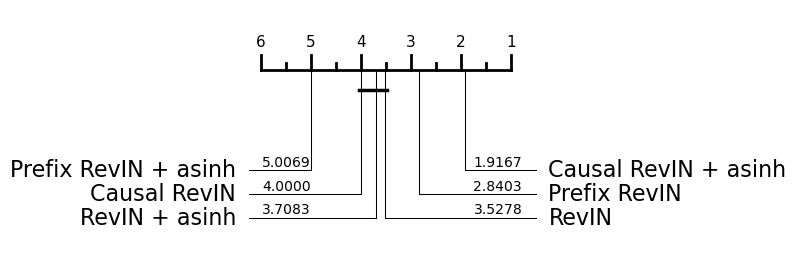

In [24]:
#MAE

df_mae = pd.DataFrame(new_df_mae)
methods = df_mae.columns
plot = plot_critical_difference(df_mae.values, methods, alpha=0.05, width=4, textspace=1, test='nemenyi', lower_better=True)

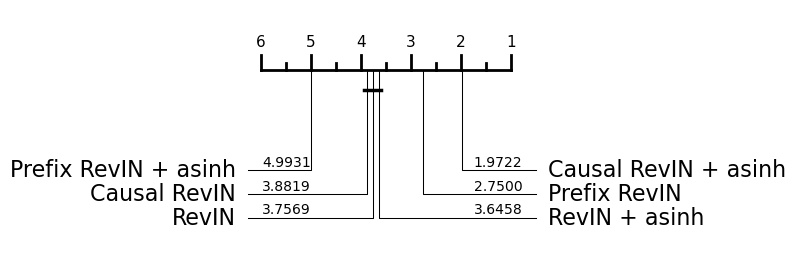

In [25]:
#MSE

df_mse = pd.DataFrame(new_df_mse)
methods = df_mse.columns
plot = plot_critical_difference(df_mse.values, methods, alpha=0.05, width=5, test='nemenyi', lower_better=True)

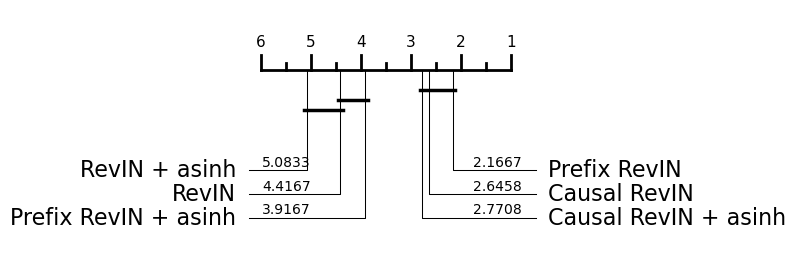

In [26]:
#MASE

df_mase = pd.DataFrame(new_df_mase)
methods = df_mase.columns
plot = plot_critical_difference(df_mase.values, methods, alpha=0.05, width=4, textspace=1, test='nemenyi', lower_better=True)